In [ ]:
import heapq
import matplotlib.pyplot as plt
import time

In [ ]:
def manhattan_distance(state, goal):
    distance = 0
    for i in range(9):
        if state[i] == 0:
            continue
        x1, y1 = divmod(i, 3)
        x2, y2 = divmod(goal.index(state[i]), 3)
        distance += abs(x1 - x2) + abs(y1 - y2)
    return distance

In [ ]:
def misplaced_tiles(state, goal):
    return sum(1 for i in range(9) if state[i] != 0 and state[i] != goal[i])

In [ ]:
def get_neighbors(state):
    neighbors = []
    zero = state.index(0)
    x, y = divmod(zero, 3)

    for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
        nx, ny = x + dx, y + dy
        if 0 <= nx < 3 and 0 <= ny < 3:
            new = state[:]
            idx = nx * 3 + ny
            new[zero], new[idx] = new[idx], new[zero]
            neighbors.append(new)
    return neighbors

In [ ]:
def is_solvable(state):
    inv = 0
    for i in range(9):
        for j in range(i + 1, 9):
            if state[i] != 0 and state[j] != 0 and state[i] > state[j]:
                inv += 1
    return inv % 2 == 0


In [ ]:
def a_star(start, goal, heuristic):
    if not is_solvable(start):
        print("Puzzle is unsolvable")
        return None

    pq = []
    heapq.heappush(pq, (0, start))
    cost = {tuple(start): 0}
    parent = {tuple(start): None}

    while pq:
        _, current = heapq.heappop(pq)
        tuple_current = tuple(current)

        if current == goal:
            print("Goal reached")
            print("Minimum moves required:", cost[tuple_current])
            return parent

        for neighbor in get_neighbors(current):
            tuple_neighbor = tuple(neighbor)
            new_cost = cost[tuple_current] + 1

            if tuple_neighbor not in cost or new_cost < cost[tuple_neighbor]:
                cost[tuple_neighbor] = new_cost
                priority = new_cost + heuristic(neighbor, goal)
                heapq.heappush(pq, (priority, neighbor))
                parent[tuple_neighbor] = tuple_current

    return None



In [ ]:
def reconstruct_path(parent, start, goal):
    path = []
    current = tuple(goal)
    while current is not None:
        path.append(list(current))
        current = parent[current]
    return path[::-1]


In [ ]:
plt.ion()

def visualize_puzzle(state, step):
    plt.clf()
    plt.title(f"Step {step}")

    for i in range(9):
        row, col = divmod(i, 3)
        value = state[i]

        if value != 0:
            plt.text(col, row, str(value),
                     fontsize=24,
                     ha='center', va='center',
                     bbox=dict(boxstyle="round", facecolor="lightblue"))
        else:
            plt.text(col, row, " ",
                     fontsize=24,
                     ha='center', va='center',
                     bbox=dict(boxstyle="round", facecolor="white"))

    plt.xticks([0,1,2])
    plt.yticks([0,1,2])
    plt.xlim(-0.5, 2.5)
    plt.ylim(2.5, -0.5)
    plt.grid()
    plt.pause(1)


In [ ]:
def animate_solution(path):
    plt.figure(figsize=(4,4))
    for step, state in enumerate(path):
        visualize_puzzle(state, step)
    plt.ioff()
    plt.show()

Enter the initial state (9 numbers, use 0 for blank):
1 2 3 4 0 6 7 5 8

Choose heuristic:
1. Manhattan Distance
2. Misplaced Tiles
Enter choice: 1
Goal reached
Minimum moves required: 2
Number of moves: 2


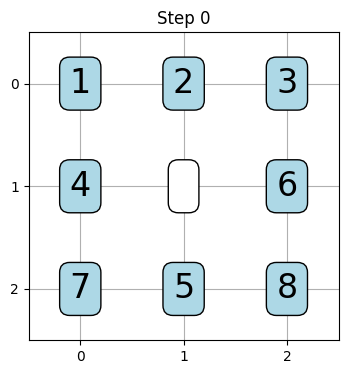

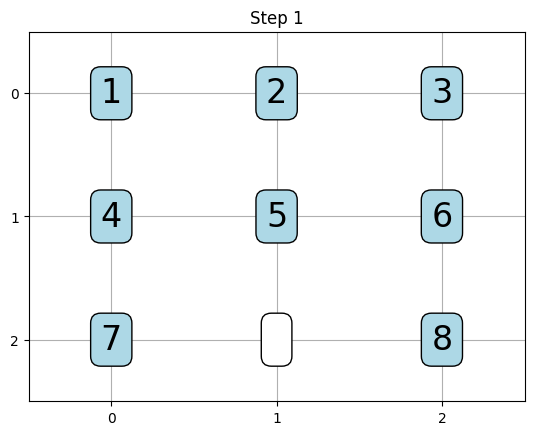

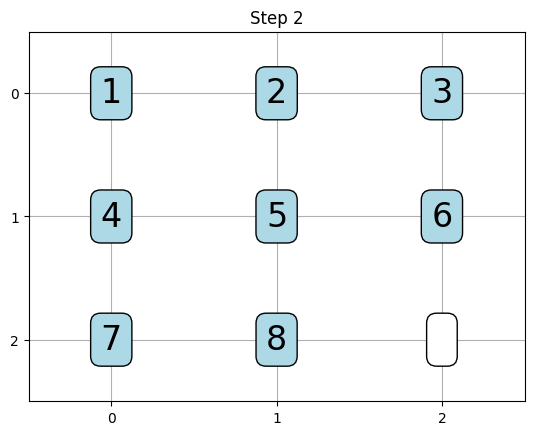

In [ ]:
print("Enter the initial state (9 numbers, use 0 for blank):")
start_state = list(map(int, input().split()))

goal_state = [1,2,3,4,5,6,7,8,0]

print("\nChoose heuristic:")
print("1. Manhattan Distance")
print("2. Misplaced Tiles")
choice = int(input("Enter choice: "))

heuristic = manhattan_distance if choice == 1 else misplaced_tiles

parent_map = a_star(start_state, goal_state, heuristic)

if parent_map is None:
    print("No solution found.")
else:
    path = reconstruct_path(parent_map, start_state, goal_state)
    print("Number of moves:", len(path)-1)
    animate_solution(path)